# Random Graph Generation

Adjacency matrix:
[[1 0 0 0 1 0 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 1 0 1 1 0]
 [0 0 0 1 0 1 1 0 0 0]
 [1 0 0 0 1 0 0 0 0 1]
 [0 0 1 1 0 1 0 0 1 1]
 [0 0 0 1 0 0 1 0 1 0]
 [0 1 1 0 0 0 0 1 0 0]
 [1 0 1 0 0 1 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 1]]


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:315: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)
/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:315: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)
/tmp/ipykernel_24439/3556996954.py:26: UserWarning: This figure includes Axes that are not compatible with tight_

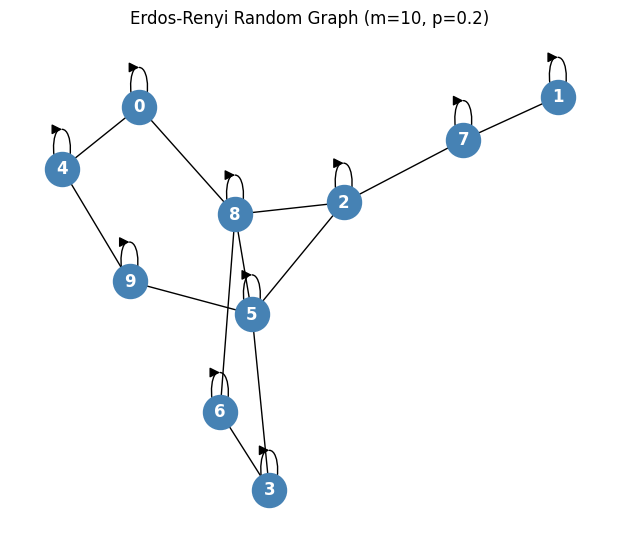

In [28]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graph import erdos_renyi_graph, erdos_renyi_digraph

seed = 42
m = 10
p = 0.2
A = erdos_renyi_graph(m=m, p=p, seed=seed)


print("Adjacency matrix:")
print(A.astype(int))

# Plot with arrows if A is directed (asymmetric); plain edges otherwise
is_directed = not np.allclose(A, A.T)
G = nx.from_numpy_array(A, create_using=nx.DiGraph if is_directed else nx.Graph)

plt.figure(figsize=(6, 5))
nx.draw(
    G, with_labels=True, node_color="steelblue", node_size=600, font_color="white", font_weight="bold",
    arrows=is_directed, arrowstyle="-|>", arrowsize=15,
    connectionstyle="arc3,rad=0.1" if is_directed else "arc3",
)
plt.title(f"Erdos-Renyi Random {'Digraph' if is_directed else 'Graph'} (m={m}, p={p})")
plt.tight_layout()
plt.show()


# Kemeny Constant


Initial Kemeny: 640694.2158
Final Kemeny:   24.7101
Iterations:     55
Adjacency matrix:
 [[1 0 0 0 1 0 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 1 0 1 1 0]
 [0 0 0 1 0 1 1 0 0 0]
 [1 0 0 0 1 0 0 0 0 1]
 [0 0 1 1 0 1 0 0 1 1]
 [0 0 0 1 0 0 1 0 1 0]
 [0 1 1 0 0 0 0 1 0 0]
 [1 0 1 0 0 1 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 1]]
Final Q:
 [[0.1336 0.     0.     0.     0.0138 0.     0.     0.     0.0533 0.    ]
 [0.     0.0665 0.     0.     0.     0.     0.     0.024  0.     0.    ]
 [0.     0.     0.0401 0.     0.     0.0393 0.     0.0274 0.0271 0.    ]
 [0.     0.     0.     0.0189 0.     0.0301 0.0389 0.     0.     0.    ]
 [0.0138 0.     0.     0.     0.     0.     0.     0.     0.     0.0105]
 [0.     0.     0.0393 0.0301 0.     0.     0.     0.     0.0023 0.0379]
 [0.     0.     0.     0.0389 0.     0.     0.0402 0.     0.0225 0.    ]
 [0.     0.024  0.0274 0.     0.     0.     0.     0.     0.     0.    ]
 [0.0533 0.     0.0271 0.     0.     0.0023 0.0225 0.     0.     0.    ]
 [0.     0.

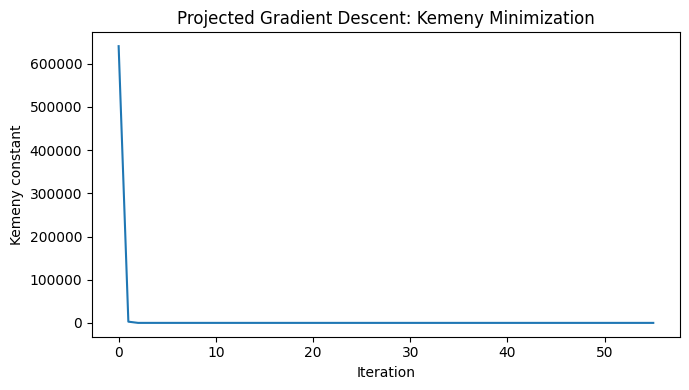

In [29]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

K_final = np.inf
while K_final > 100:
    # Random stationary distribution
    pi_bar = np.random.dirichlet(5 * np.ones(len(A)))

    # Random initial ergodic flow
    Q0 = random_chain(A, seed=seed)
    project_fn = make_project_Q_bar(A, pi_bar)
    Q0 = project_fn(Q0)

    # Projected gradient descent to minimize the Kemeny constant
    Q_opt, history, n_iters = projected_gradient_descent(Q0, _grad_kemeny, project_fn, alpha=1e-5, n_iter=100, tol=1e-2)
    K_initial = history[0]
    K_final = history[-1]

print(f"\nInitial Kemeny: {K_initial:.4f}")
print(f"Final Kemeny:   {K_final:.4f}")
print(f"Iterations:     {n_iters}")

print(f"Adjacency matrix:\n {A.astype(int)}")
np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

print("pi_bar:", np.round(pi_bar, 4))
print(f"Final row sums: {np.round(Q_opt.sum(axis=1), 4)}")
print(f"Final col sums: {np.round(Q_opt.sum(axis=0), 4)}")

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Kemeny constant")
plt.title("Projected Gradient Descent: Kemeny Minimization")
plt.tight_layout()
plt.show()


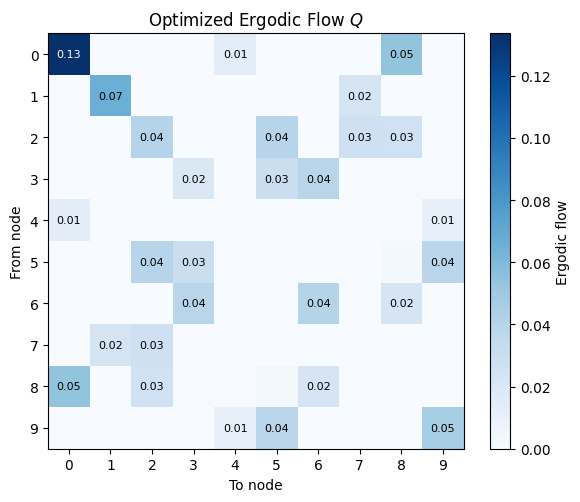

max |Q - Q^T| = 0.0000  (0 => reversible)


In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Q_opt, cmap="Blues", vmin=0, vmax=Q_opt.max())
ax.set_xlabel("To node")
ax.set_ylabel("From node")
ax.set_title("Optimized Ergodic Flow $Q$")
ax.set_xticks(range(m))
ax.set_yticks(range(m))
fig.colorbar(im, ax=ax, label="Ergodic flow")

for i in range(m):
    for j in range(m):
        if Q_opt[i, j] > 1e-2:
            ax.text(j, i, f"{Q_opt[i, j]:.2f}", ha="center", va="center",
                     color="white" if Q_opt[i, j] > 0.5 * Q_opt.max() else "black", fontsize=8)

plt.tight_layout()
plt.show()

print(f"max |Q - Q^T| = {np.abs(Q_opt - Q_opt.T).max():.4f}  (0 => reversible)")


Physical nodes m=10, lifted states n=24
A_lift:
 [[1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0]
 [1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0]
 [0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1

/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



K^lift initial:  8017.6977
K^lift final:    16.4188
K(Q_opt):        24.7101
Iterations:      100


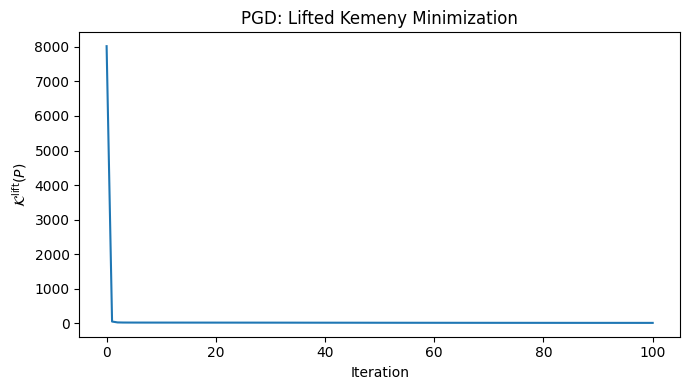

In [31]:
from graph import degree_lifting, random_chain
from optimize import _grad_lifted_kemeny, make_project_Q, projected_gradient_descent

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")
# print("V:\n", V)

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
print("A_lift:\n", A_lift.astype(int))
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

val_init, _ = _grad_lifted_kemeny(Q_lift_0, V, pi_bar)
K_opt, _ = _grad_kemeny(Q_opt)
print(f"\nK^lift (initial):    {val_init:.4f}")
print(f"K(Q_opt) [upper bd]: {K_opt:.4f}")

# --- PGD to minimize K^lift subject to Q being a lifting of Q_opt ---
grad_fn_lift = lambda Q: _grad_lifted_kemeny(Q, V, pi_bar)
Q_lift_opt, history_lift, n_iters_lift = projected_gradient_descent(
    Q_lift_0, grad_fn_lift, project_fn_lift, alpha=1e-5, n_iter=100, tol=1e-2
)

print(f"\nK^lift initial:  {history_lift[0]:.4f}")
print(f"K^lift final:    {history_lift[-1]:.4f}")
print(f"K(Q_opt):        {K_opt:.4f}")
print(f"Iterations:      {n_iters_lift}")

plt.figure(figsize=(7, 4))
plt.plot(history_lift)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Kemeny Minimization")
plt.tight_layout()
plt.show()


# Random Digraph Generation

Adjacency matrix:
[[1 0 0 0 0 0 0 0 1 0]
 [0 1 0 1 1 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 1 0 0 0]
 [1 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 1]
 [0 0 0 1 0 0 1 1 1 0]
 [1 0 0 0 0 1 0 1 0 0]
 [0 1 0 0 0 1 0 0 1 1]
 [0 0 1 1 0 1 0 0 0 1]]


/tmp/ipykernel_24439/3648800272.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


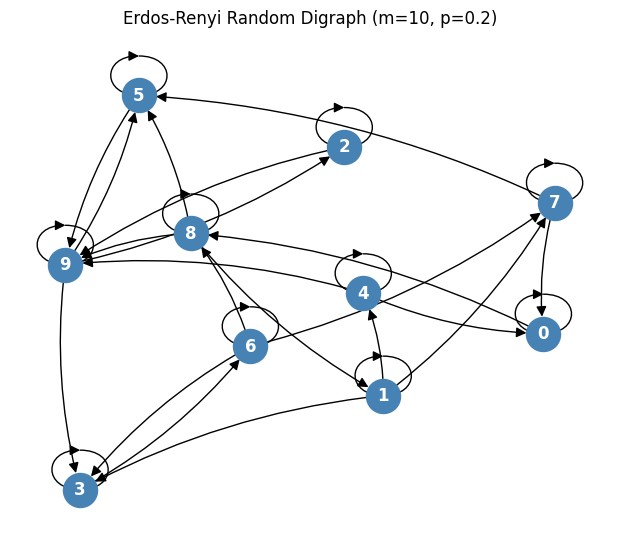

In [32]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from graph import erdos_renyi_graph, erdos_renyi_digraph

seed = 42
m = 10
p = 0.2
A = erdos_renyi_digraph(m=m, p=p, seed=seed)


print("Adjacency matrix:")
print(A.astype(int))

# Plot with arrows if A is directed (asymmetric); plain edges otherwise
is_directed = not np.allclose(A, A.T)
G = nx.from_numpy_array(A, create_using=nx.DiGraph if is_directed else nx.Graph)

plt.figure(figsize=(6, 5))
nx.draw(
    G, with_labels=True, node_color="steelblue", node_size=600, font_color="white", font_weight="bold",
    arrows=is_directed, arrowstyle="-|>", arrowsize=15,
    connectionstyle="arc3,rad=0.1" if is_directed else "arc3",
)
plt.title(f"Erdos-Renyi Random {'Digraph' if is_directed else 'Graph'} (m={m}, p={p})")
plt.tight_layout()
plt.show()


# Kemeny Constant


Initial Kemeny: 1425994.9273
Final Kemeny:   15.2126
Iterations:     90
Adjacency matrix:
 [[1 0 0 0 0 0 0 0 1 0]
 [0 1 0 1 1 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 1 0 0 0]
 [1 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 1]
 [0 0 0 1 0 0 1 1 1 0]
 [1 0 0 0 0 1 0 1 0 0]
 [0 1 0 0 0 1 0 0 1 1]
 [0 0 1 1 0 1 0 0 0 1]]
Final Q:
 [[0.0399 0.     0.     0.     0.     0.     0.     0.     0.0458 0.    ]
 [0.     0.0446 0.     0.     0.0461 0.     0.     0.     0.     0.    ]
 [0.     0.     0.1255 0.     0.     0.     0.     0.     0.     0.0451]
 [0.     0.     0.     0.0216 0.     0.     0.0657 0.     0.     0.    ]
 [0.0062 0.     0.     0.     0.0745 0.     0.     0.     0.     0.0399]
 [0.     0.     0.     0.     0.     0.0677 0.     0.     0.     0.0319]
 [0.     0.     0.     0.003  0.     0.     0.0375 0.0568 0.0059 0.    ]
 [0.0396 0.     0.     0.     0.     0.0172 0.     0.017  0.     0.    ]
 [0.     0.0461 0.     0.     0.     0.0056 0.     0.     0.     0.    ]
 [0.     0

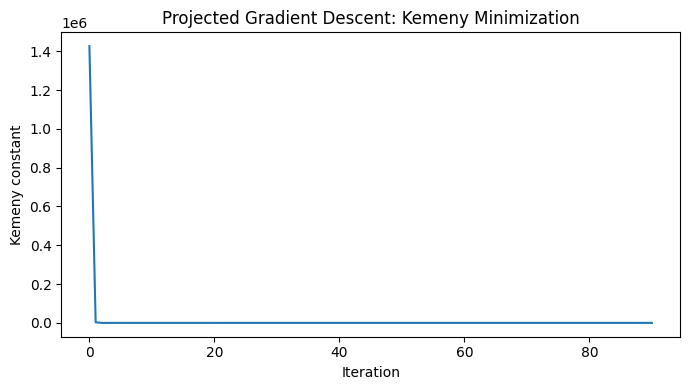

In [33]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

K_final = np.inf
while K_final > 100:
    # Random stationary distribution
    pi_bar = np.random.dirichlet(5 * np.ones(len(A)))

    # Random initial ergodic flow
    Q0 = random_chain(A, seed=seed)
    project_fn = make_project_Q_bar(A, pi_bar)
    Q0 = project_fn(Q0)

    # Projected gradient descent to minimize the Kemeny constant
    Q_opt, history, n_iters = projected_gradient_descent(Q0, _grad_kemeny, project_fn, alpha=1e-5, n_iter=100, tol=1e-2)
    K_initial = history[0]
    K_final = history[-1]

print(f"\nInitial Kemeny: {K_initial:.4f}")
print(f"Final Kemeny:   {K_final:.4f}")
print(f"Iterations:     {n_iters}")

print(f"Adjacency matrix:\n {A.astype(int)}")
np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

print("pi_bar:", np.round(pi_bar, 4))
print(f"Final row sums: {np.round(Q_opt.sum(axis=1), 4)}")
print(f"Final col sums: {np.round(Q_opt.sum(axis=0), 4)}")

plt.figure(figsize=(7, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Kemeny constant")
plt.title("Projected Gradient Descent: Kemeny Minimization")
plt.tight_layout()
plt.show()


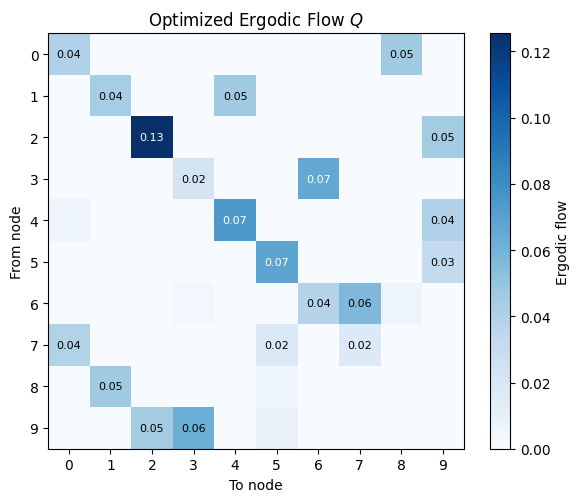

max |Q - Q^T| = 0.0627  (0 => reversible)


In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Q_opt, cmap="Blues", vmin=0, vmax=Q_opt.max())
ax.set_xlabel("To node")
ax.set_ylabel("From node")
ax.set_title("Optimized Ergodic Flow $Q$")
ax.set_xticks(range(m))
ax.set_yticks(range(m))
fig.colorbar(im, ax=ax, label="Ergodic flow")

for i in range(m):
    for j in range(m):
        if Q_opt[i, j] > 1e-2:
            ax.text(j, i, f"{Q_opt[i, j]:.2f}", ha="center", va="center",
                     color="white" if Q_opt[i, j] > 0.5 * Q_opt.max() else "black", fontsize=8)

plt.tight_layout()
plt.show()

print(f"max |Q - Q^T| = {np.abs(Q_opt - Q_opt.T).max():.4f}  (0 => reversible)")


Physical nodes m=10, lifted states n=20
A_lift:
 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0]
 [0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1]
 [1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0]
 [0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1]
 [0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1]
 [0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1]]

K^lift (initial):    546.4354
K(Q_opt) [upper bd]: 15.2126

K^lift initial:  546.4354
K^l

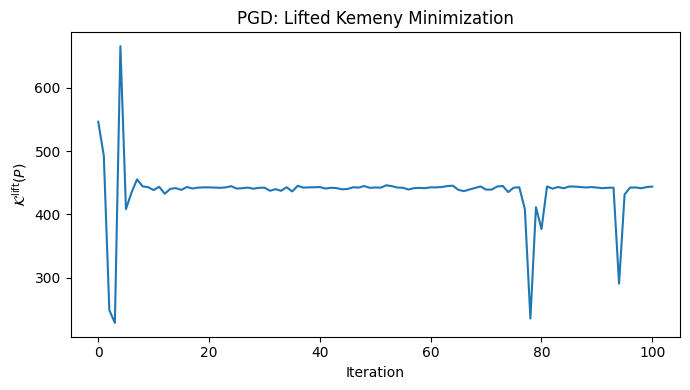

In [35]:
from graph import degree_lifting, random_chain
from optimize import _grad_lifted_kemeny, make_project_Q, projected_gradient_descent

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")
# print("V:\n", V)

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
print("A_lift:\n", A_lift.astype(int))
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

val_init, _ = _grad_lifted_kemeny(Q_lift_0, V, pi_bar)
K_opt, _ = _grad_kemeny(Q_opt)
print(f"\nK^lift (initial):    {val_init:.4f}")
print(f"K(Q_opt) [upper bd]: {K_opt:.4f}")

# --- PGD to minimize K^lift subject to Q being a lifting of Q_opt ---
grad_fn_lift = lambda Q: _grad_lifted_kemeny(Q, V, pi_bar)
Q_lift_opt, history_lift, n_iters_lift = projected_gradient_descent(
    Q_lift_0, grad_fn_lift, project_fn_lift, alpha=1e-5, n_iter=100, tol=1e-2
)

print(f"\nK^lift initial:  {history_lift[0]:.4f}")
print(f"K^lift final:    {history_lift[-1]:.4f}")
print(f"K(Q_opt):        {K_opt:.4f}")
print(f"Iterations:      {n_iters_lift}")

plt.figure(figsize=(7, 4))
plt.plot(history_lift)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Kemeny Minimization")
plt.tight_layout()
plt.show()


# Stackelberg Game Metric

Attack duration tau: [4 4 4 4 4 4 4 4 4 4]
Softmin temperature: 0.001 -> 1e-06

Initial J: 0.0008
Final J:   0.0470
Iterations: 173
Final Q:
 [[0.     0.3474 0.     0.7339 0.     0.     0.731  0.6377 0.4633 0.    ]
 [0.5557 0.     0.     0.     0.     0.     0.     0.     0.     0.375 ]
 [0.     0.     0.8073 0.     0.0651 0.     0.     0.     0.2226 0.372 ]
 [0.7339 0.     0.     0.2255 0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.1132 0.     0.5515 0.4542 0.     0.1719 0.4425 0.0436]
 [0.     0.     0.     0.     0.3103 0.279  0.     0.     0.     0.6647]
 [0.7309 0.     0.     0.     0.     0.     0.1987 0.     0.     0.    ]
 [0.269  0.     0.     0.     0.5405 0.     0.     0.     0.     0.    ]
 [0.6236 0.0386 0.3865 0.     0.2721 0.     0.     0.     0.     0.0795]
 [0.     0.5448 0.16   0.     0.0374 0.5208 0.     0.     0.2719 0.    ]]


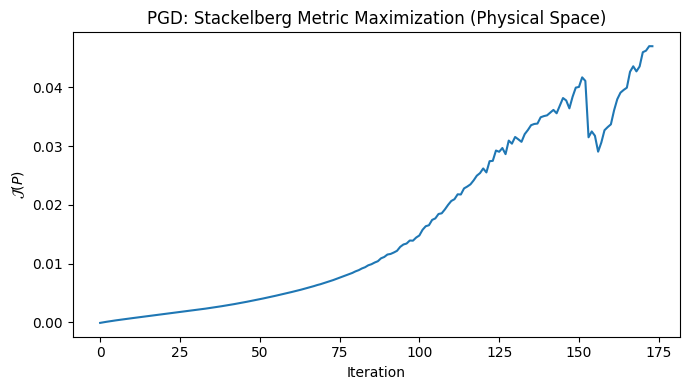

In [17]:
import networkx as nx
from graph import random_chain
from optimize import make_grad_stackelberg, make_project_Q_bar, projected_gradient_descent
from metrics import stackelberg
from markov import ergodic_flow_to_transition

# Attack duration tau: set uniformly to the graph diameter (smallest duration that
# guarantees nonzero capture probability from any node to any other, Sec. IX)
A_no_self = A - np.diag(np.diag(A))
diameter = nx.diameter(nx.from_numpy_array(A_no_self))
tau = diameter * np.ones(m, dtype=int)

# V defaults to I_m, collapsing the lifted Stackelberg metric to the standard
# physical-space metric J(P) (Eq. 38)
grad_stackelberg = make_grad_stackelberg(tau)
# Free stationary distribution; epsilon=0 since the metric itself penalizes
# reducibility (Sec. IX)
project_fn_stb = make_project_Q_bar(A, pi_bar=None, epsilon=0.0)

# J is to be maximized, so PGD minimizes the negated metric/gradient. Anneal the
# softmin temperature from temp0 (smooth, informative gradients early on) down to
# temp_min (tight approximation to the true min(Psi_lift)) via geometric decay.
n_iter_stb = 200
temp0, temp_min = 1e-3, 1e-6
temp_decay = (temp_min / temp0) ** (1 / n_iter_stb)
temp_schedule_stb = lambda k: temp0 * temp_decay ** k
neg_grad_stackelberg = lambda Q, lse_temp: tuple(-x for x in grad_stackelberg(Q, lse_temp))

Q0 = random_chain(A, seed=seed)
Q0 = project_fn_stb(Q0)

Q_opt, hist, n_iters = projected_gradient_descent(
    Q0, neg_grad_stackelberg, project_fn_stb, alpha=1, n_iter=n_iter_stb, tol=1e-5,
    temp_schedule=temp_schedule_stb,
)

print(f"Attack duration tau: {tau}")
print(f"Softmin temperature: {temp0:.4g} -> {temp_min:.4g}")

P0 = ergodic_flow_to_transition(Q0)
J_initial = stackelberg(P0, tau)
P_opt = ergodic_flow_to_transition(Q_opt)
J_final = stackelberg(P_opt, tau)

print(f"\nInitial J: {J_initial:.4f}")
print(f"Final J:   {J_final:.4f}")
print(f"Iterations: {n_iters}")

np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")

plt.figure(figsize=(7, 4))
plt.plot([-v for v in hist])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{J}(P)$")
plt.title("PGD: Stackelberg Metric Maximization (Physical Space)")
plt.tight_layout()
plt.show()


Physical nodes m=10, lifted states n=32
J(Q_opt) [physical]: 0.0470


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



J^lift initial:  0.0049
J^lift final:    0.1200
Iterations:      200


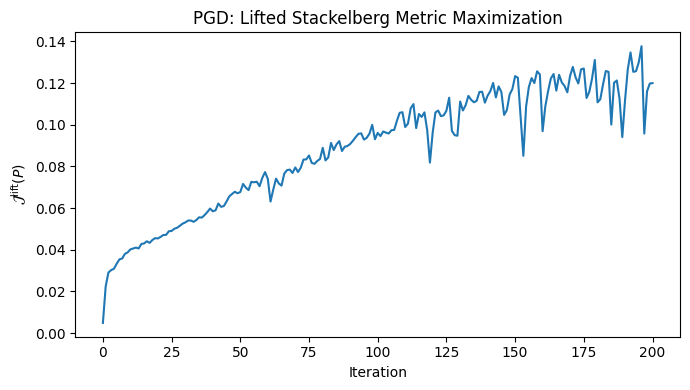

In [18]:
from graph import degree_lifting, random_chain
from optimize import make_grad_stackelberg, make_project_Q, projected_gradient_descent
from metrics import lifted_stackelberg
from markov import ergodic_flow_to_transition

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

grad_stackelberg_lift = make_grad_stackelberg(tau, V)
neg_grad_stackelberg_lift = lambda Q, lse_temp: tuple(-x for x in grad_stackelberg_lift(Q, lse_temp))

print(f"J(Q_opt) [physical]: {J_final:.4f}")

# --- PGD to maximize J^lift subject to Q being a lifting of Q_opt ---
Q_lift_opt, hist_lift, n_iters_lift = projected_gradient_descent(
    Q_lift_0, neg_grad_stackelberg_lift, project_fn_lift, alpha=0.1, n_iter=n_iter_stb, tol=1e-6,
    temp_schedule=temp_schedule_stb,
)

P_lift_opt = ergodic_flow_to_transition(Q_lift_opt)
J_lift_final = lifted_stackelberg(P_lift_opt, V, tau)

print(f"\nJ^lift initial:  {-hist_lift[0]:.4f}")
print(f"J^lift final:    {J_lift_final:.4f}")
print(f"Iterations:      {n_iters_lift}")

plt.figure(figsize=(7, 4))
plt.plot([-v for v in hist_lift])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{J}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Stackelberg Metric Maximization")
plt.tight_layout()
plt.show()


# RTE Metric


Initial H: 0.0000
Final H:   2.6300
Iterations: 200
Final Q:
 [[0.0314 0.     0.     0.     0.0737 0.     0.     0.     0.0054 0.    ]
 [0.     0.0217 0.     0.     0.     0.     0.     0.0405 0.     0.    ]
 [0.     0.     0.0165 0.     0.     0.     0.     0.048  0.0356 0.    ]
 [0.     0.     0.     0.0501 0.     0.     0.065  0.     0.     0.    ]
 [0.0258 0.     0.     0.     0.0199 0.     0.     0.     0.     0.0744]
 [0.     0.     0.0082 0.0398 0.     0.039  0.     0.     0.     0.    ]
 [0.     0.     0.     0.0252 0.     0.     0.0092 0.     0.0398 0.    ]
 [0.     0.0405 0.048  0.     0.     0.     0.     0.035  0.     0.    ]
 [0.0533 0.     0.0275 0.     0.     0.     0.     0.     0.0189 0.    ]
 [0.     0.     0.     0.     0.0264 0.048  0.     0.     0.     0.0329]]
pi_bar: [0.1105 0.0622 0.1001 0.1152 0.1201 0.087  0.0742 0.1236 0.0997 0.1073]


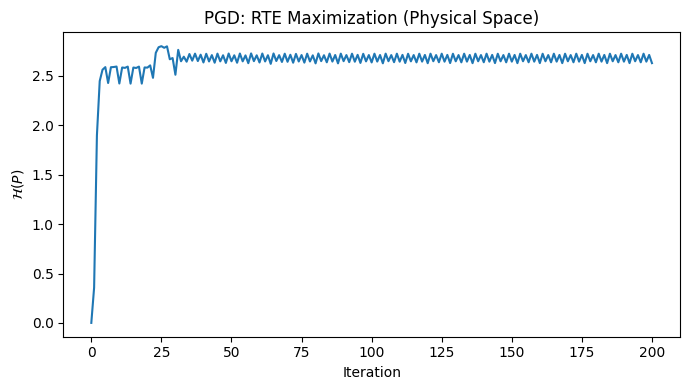

In [40]:
from graph import random_chain
from optimize import make_grad_rte, make_project_Q_bar, projected_gradient_descent
from metrics import return_time_entropy
from markov import ergodic_flow_to_transition

eta = 0.25

# Random stationary distribution
pi_bar = np.random.dirichlet(5 * np.ones(len(A)))

# Random initial ergodic flow
Q0 = random_chain(A, seed=seed)
project_fn_rte = make_project_Q_bar(A, pi_bar)
Q0 = project_fn_rte(Q0)

# V defaults to I_m, collapsing the lifted RTE metric to the standard physical-space
# metric H(P) (Eq. 43). In that case pi_bar must equal the stationary distribution
# itself, which holds here since project_fn_rte fixes Q's row sums to pi_bar.
grad_rte = make_grad_rte(pi_bar, eta)

# H is to be maximized, so PGD minimizes the negated metric/gradient.
neg_grad_rte = lambda Q: tuple(-x for x in grad_rte(Q))

Q_opt, history, n_iters = projected_gradient_descent(
    Q0, neg_grad_rte, project_fn_rte, alpha=0.01, n_iter=200, tol=1e-6
)

P0 = ergodic_flow_to_transition(Q0)
H_initial = return_time_entropy(P0, eta=eta)
P_opt = ergodic_flow_to_transition(Q_opt)
H_final = return_time_entropy(P_opt, eta=eta)

print(f"\nInitial H: {H_initial:.4f}")
print(f"Final H:   {H_final:.4f}")
print(f"Iterations: {n_iters}")

np.set_printoptions(precision=6, suppress=True)
print(f"Final Q:\n {np.round(Q_opt, 4)}")
print("pi_bar:", np.round(pi_bar, 4))

plt.figure(figsize=(7, 4))
plt.plot([-v for v in history])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{H}(P)$")
plt.title("PGD: RTE Maximization (Physical Space)")
plt.tight_layout()
plt.show()


Physical nodes m=10, lifted states n=24
H(Q_opt) [physical]: 2.6300

H^lift initial:  2.1390
H^lift final:    2.6396
Iterations:      200


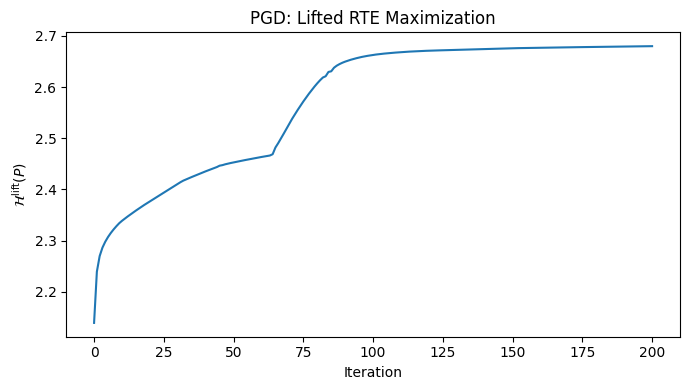

In [41]:
from graph import degree_lifting, random_chain
from optimize import make_grad_rte, make_project_Q, projected_gradient_descent
from metrics import lifted_return_time_entropy
from markov import ergodic_flow_to_transition

# --- Degree lifting: node j gets deg(j) virtual states ---
V = degree_lifting(A)
n, m = V.shape

print(f"Physical nodes m={m}, lifted states n={n}")

# --- Random initialization in the lifted space ---
eps = 1e-6
Q_opt_ceil = (Q_opt > eps).astype(int)
A_lift = V @ Q_opt_ceil @ V.T
Q_lift_init = random_chain(A_lift, seed=seed)

# Project onto the feasible lifting set of Q_opt (Eq. 34)
project_fn_lift = make_project_Q(Q_opt, V)
Q_lift_0 = project_fn_lift(Q_lift_init)

# pi_bar is the (fixed) physical stationary distribution associated with Q_opt,
# i.e. Q_opt's row sums, held fixed by the lifting constraint V^T Q V = Q_opt
grad_rte_lift = make_grad_rte(pi_bar, eta, V)

# H^lift is to be maximized, so PGD minimizes the negated metric/gradient.
neg_grad_rte_lift = lambda Q: tuple(-x for x in grad_rte_lift(Q))

print(f"H(Q_opt) [physical]: {H_final:.4f}")

# --- PGD to maximize H^lift subject to Q being a lifting of Q_opt ---
Q_lift_opt, hist_lift, n_iters_lift = projected_gradient_descent(
    Q_lift_0, neg_grad_rte_lift, project_fn_lift, alpha=1e-3, n_iter=200, tol=1e-6
)

P_lift_opt = ergodic_flow_to_transition(Q_lift_opt)
H_lift_final = lifted_return_time_entropy(P_lift_opt, V, eta=eta)

print(f"\nH^lift initial:  {-hist_lift[0]:.4f}")
print(f"H^lift final:    {H_lift_final:.4f}")
print(f"Iterations:      {n_iters_lift}")

plt.figure(figsize=(7, 4))
plt.plot([-v for v in hist_lift])
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{H}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted RTE Maximization")
plt.tight_layout()
plt.show()


# Miscellaneous

In [26]:
import networkx as nx
from graph import san_francisco_graph, prune_long_edges

A_sf, W_sf, pi_bar_sf = san_francisco_graph()
w_max = 4
A_sf_pruned = prune_long_edges(A_sf, W_sf, threshold=w_max)

G_sf = nx.from_numpy_array(A_sf_pruned * W_sf, create_using=nx.DiGraph)
lengths_sf = dict(nx.all_pairs_dijkstra_path_length(G_sf, weight="weight"))
weighted_diameter = max(d for targets in lengths_sf.values() for d in targets.values())

print(f"Weighted diameter (w_max={w_max}): {weighted_diameter}")


Weighted diameter (w_max=4): 13.0
